# Intro to Clustering in Python

**Author:** Alexander Michels

This notebook walks through the basics of clustering in Python, specifically k-means and DBSCAN.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans, vq
import seaborn as sb
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

scipy has a `make_blobs` function that will create clustered data for us to explore the methods.

In [2]:
dataset = make_blobs(n_samples=200,
                     centers=4,
                     n_features=2,
                     cluster_std=1.6,
                     random_state=50)

The function returns two objects: the data and the labels for the data (the clusters).

In [3]:
dataset

(array([[-1.06705283e+00,  9.24306355e+00],
        [ 1.08654318e+00, -6.94815805e+00],
        [-2.30970265e+00,  5.84969440e+00],
        [-1.59728965e+00,  8.45369045e+00],
        [-5.79816711e+00, -3.78405528e+00],
        [-2.29833776e+00, -4.66005371e+00],
        [-1.68210799e+00,  1.12843423e+01],
        [-7.38296450e-01, -5.20135260e+00],
        [-1.92048345e-01, -6.45318764e+00],
        [-6.37920287e+00, -2.17672355e+00],
        [-5.12054803e+00, -2.91449176e+00],
        [-4.22297649e+00,  9.04719945e+00],
        [-2.67815731e+00, -2.32828819e+00],
        [-3.02994109e+00,  1.86959382e+00],
        [-5.73938121e+00, -7.25648845e-01],
        [-1.99427571e+00,  4.28616868e+00],
        [-2.89522086e+00,  1.10222354e+01],
        [-1.11286937e+00,  1.03086380e+01],
        [-5.19987051e+00, -1.59879364e+00],
        [-4.75916597e+00, -1.97047767e+00],
        [-6.76865308e+00, -3.56907573e+00],
        [-2.65715781e+00,  3.33763714e+00],
        [-4.61722463e+00,  1.063

In [4]:
points = dataset[0]  # lets grab the data
labels = dataset[1]  # lets grab the labels

## k-Means

We can create a k-means model with scipy as well by passing it our data and our guess for how many clusters there are. Documentation on the function: https://docs.scipy.org/doc/scipy-1.13.0/reference/generated/scipy.cluster.vq.kmeans.html#scipy.cluster.vq.kmeans

In [5]:
model = kmeans(points, k_or_guess=4)

The kmeans function returns a k by N array of the centroids and a measure of the fitness called the distortion: https://docs.scipy.org/doc/scipy-1.13.0/reference/generated/scipy.cluster.vq.kmeans.html

In [6]:
model

(array([[ 0.05161133, -5.35489826],
        [-1.92101646,  5.21673484],
        [-5.56465793, -2.34988939],
        [-2.40167949, 10.17352695]]),
 1.8774813896990004)

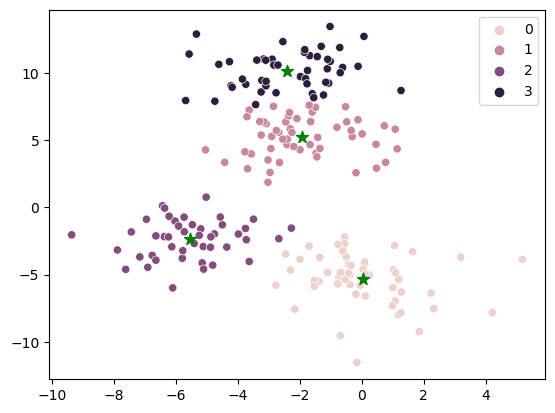

In [7]:
centroids = model[0]  # save the centroids as a variable called centroids
cluster_num = vq(points, centroids)[0]  # get the cluster number

# scatter plot of K-Means cluster
sb.scatterplot(x=points[:, 0],
               y=points[:, 1],
               hue=cluster_num)

# Centroid of the clusters
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            marker='*',
            s=80,
            color='green')

Let's try again with the data not scaled to demonstrate the importance of standardization!

In [8]:
scaled_data = points * [1, 10]

<Axes: >

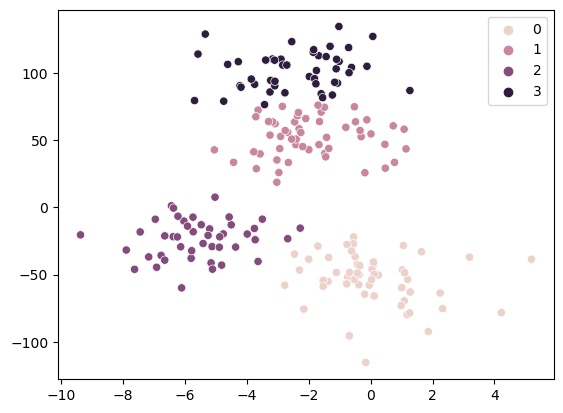

In [9]:
# scatter plot of K-Means cluster
sb.scatterplot(x=scaled_data[:, 0],
               y=scaled_data[:, 1],
               hue=cluster_num)

In [10]:
scaled_model = kmeans(scaled_data, k_or_guess=4)

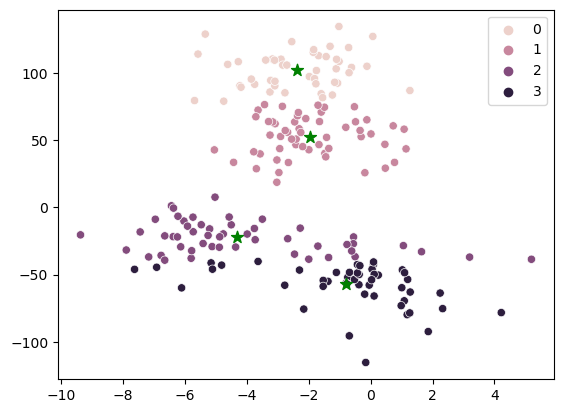

In [11]:
centroids = scaled_model[0]
cluster_num = vq(scaled_data, centroids)[0]  # get the cluster number

# scatter plot of K-Means cluster
sb.scatterplot(x=scaled_data[:, 0],
               y=scaled_data[:, 1],
               hue=cluster_num)

# Centroid of the clusters
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            marker='*',
            s=80,
            color='green')

## DBSCAN

Now we will use a density-based approach called DBSCAN. The following code is adapted from: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

DBSCAN documentation: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [15]:
# eps is our distance, min_sample is the minimum points to be a cluster
db = DBSCAN(eps=1.2, min_samples=2).fit(points)

With our fitted model, we can get the number of clusters and the "noise points" or outliers.

In [13]:
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 16


Now we can plot our result:

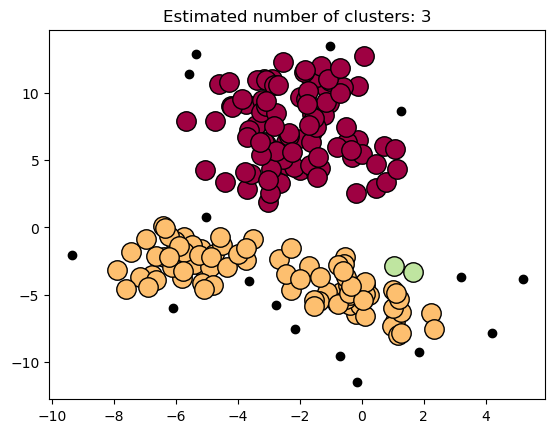

In [14]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = points[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = points[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()